# Proyecto Final – Sistema de Recomendación para E-commerce

## Notebook 4: Modelos de clasificación – predicción de categoría de compra

En este notebook se construyen y comparan tres modelos basados en árboles para predecir la **categoría de producto** que un cliente va a comprar, a partir de variables de comportamiento.

Los modelos comparados son:

- **Random Forest**
- **XGBoost**
- **LightGBM**

Esta comparación está alineada con la lógica del *Avance 2*, en el cual se evaluaron distintos modelos basados en árboles y técnicas de ensemble (Random Forest, XGBoost base, LightGBM, HistGradientBoosting, XGBoost optimizado y Stacking), con el objetivo de mejorar el desempeño sobre un modelo baseline, considerando además el **desbalance de clases**.

## Objetivo

- Predecir `product_category_name` a partir de variables de cliente y producto.
- Comparar tres modelos (Random Forest, XGBoost, LightGBM) bajo las mismas condiciones de entrenamiento.
- Analizar métricas considerando el desbalance de clases (Accuracy, F1 macro, F1 weighted).
- Identificar el modelo con mejor desempeño y discutir sus ventajas.

## Variables utilizadas

- `customer_purchase_count` – cantidad de compras históricas del cliente.
- `product_popularity` – popularidad del producto (n° interacciones).
- `product_rating` – rating promedio del producto.
- `customer_total_spend` – gasto total acumulado del cliente.
- `days_since_last_purchase` – días desde la última compra.

**Target:** `product_category_name` (multi-clase).

In [63]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 1. Carga del dataset

In [64]:
data_path = os.path.join("..", "data", "dataset_modelo.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,0
1,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,pet_shop,2,1,4.000000,284.56,146
2,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,1,3,4.333333,216.87,0
3,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,perfumaria,1,2,4.000000,25.78,0
4,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,1,12,3.833333,218.04,0


In [65]:
print("Valores nulos por columna:")
print(df.isna().sum())
print("\nCategorías únicas:", df["product_category_name"].nunique())

Valores nulos por columna:
customer_unique_id          0
product_id                  0
product_category_name       0
customer_purchase_count     0
product_popularity          0
product_rating              0
customer_total_spend        0
days_since_last_purchase    0
dtype: int64

Categorías únicas: 73


## 2. Exploración del target y tratamiento del desbalance

El dataset contiene 73 categorías, muchas con muy pocas observaciones. Esto genera un fuerte desbalance de clases que impacta directamente el entrenamiento.

**Decisión metodológica:** se conservan únicamente las **Top 15 categorías** más frecuentes, que concentran la mayor parte de las interacciones. Esta estrategia:

- mantiene un problema realista (las categorías long-tail tienen muy poca señal);
- mejora la estabilidad del entrenamiento multi-clase;
- permite una comparación más justa entre modelos.

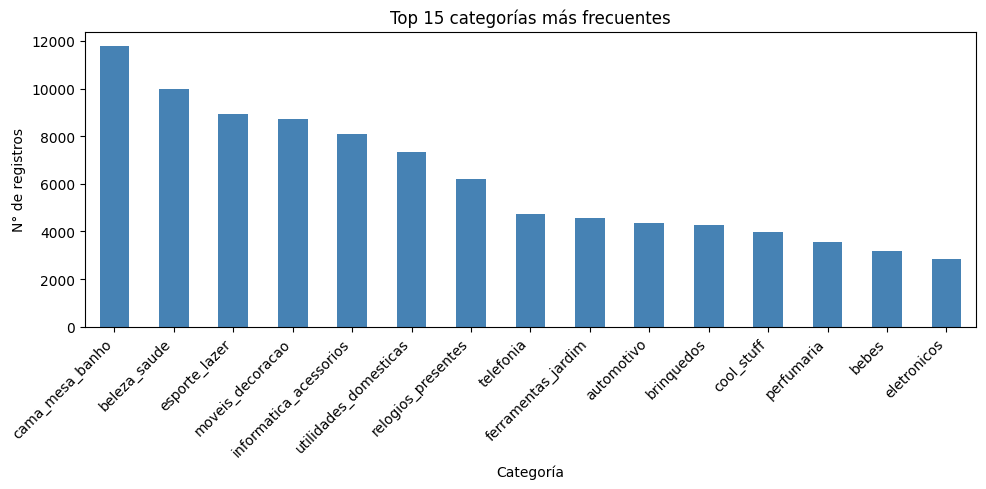

Participación Top 15: 79.94 %


In [66]:
cat_counts = df["product_category_name"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
cat_counts.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 15 categorías más frecuentes")
ax.set_ylabel("N° de registros")
ax.set_xlabel("Categoría")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Participación Top 15:", round(cat_counts.head(15).sum() / cat_counts.sum() * 100, 2), "%")

In [67]:
TOP_N = 15
top_categories = cat_counts.head(TOP_N).index.tolist()

df_model = df[df["product_category_name"].isin(top_categories)].copy()
print("Shape dataset filtrado:", df_model.shape)
print("Clases finales:", df_model["product_category_name"].nunique())

Shape dataset filtrado: (92490, 8)
Clases finales: 15


## 3. Preparación de features y target

In [68]:
features = [
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase",
]

X = df_model[features].copy()

le = LabelEncoder()
y = le.fit_transform(df_model["product_category_name"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases codificadas:", len(le.classes_))

X shape: (92490, 5)
y shape: (92490,)
Clases codificadas: 15


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (73992, 5) Test: (18498, 5)


## 4. Entrenamiento de los tres modelos

Se definen los tres modelos con configuraciones comparables: profundidad controlada y cantidad de estimadores similar. Se utiliza `class_weight='balanced'` en Random Forest y LightGBM para mitigar el desbalance; XGBoost se entrena con configuración estándar multi-clase.

In [70]:
def entrenar_y_evaluar(nombre, modelo, X_train, y_train, X_test, y_test):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo_fit = time.time() - t0

    y_pred = modelo.predict(X_test)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "Tiempo_fit_seg": round(tiempo_fit, 2),
    }

    print(f"\n=== {nombre} ===")
    for k, v in metrics.items():
        if k != "Modelo":
            print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics, y_pred, modelo

In [71]:
# ================================
# BASELINE MODEL (DummyClassifier)
# ================================

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

metrics_dummy, pred_dummy, dummy = entrenar_y_evaluar(
    "Baseline (most_frequent)",
    dummy,
    X_train,
    y_train,
    X_test,
    y_test
)


=== Baseline (most_frequent) ===
Accuracy: 0.1275
F1_macro: 0.0151
F1_weighted: 0.0288
Tiempo_fit_seg: 0.0100


### 4.1 Random Forest

In [72]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_rf, pred_rf, rf = entrenar_y_evaluar(
    "Random Forest", rf, X_train, y_train, X_test, y_test
)


=== Random Forest ===
Accuracy: 0.3885
F1_macro: 0.4055
F1_weighted: 0.4062
Tiempo_fit_seg: 8.6600


### 4.2 XGBoost

In [73]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_xgb, pred_xgb, xgb = entrenar_y_evaluar(
    "XGBoost", xgb, X_train, y_train, X_test, y_test
)


=== XGBoost ===
Accuracy: 0.5823
F1_macro: 0.6010
F1_weighted: 0.5892
Tiempo_fit_seg: 38.9600


### 4.3 LightGBM

In [74]:
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    num_leaves=63,
    learning_rate=0.1,
    class_weight="balanced",
    objective="multiclass",
    num_class=len(le.classes_),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

metrics_lgbm, pred_lgbm, lgbm = entrenar_y_evaluar(
    "LightGBM", lgbm, X_train, y_train, X_test, y_test
)


=== LightGBM ===
Accuracy: 0.6043
F1_macro: 0.6001
F1_weighted: 0.6145
Tiempo_fit_seg: 33.1100


## 5. Comparación de los tres modelos

In [75]:
comparacion = pd.DataFrame([metrics_dummy, metrics_rf, metrics_xgb, metrics_lgbm])
comparacion = comparacion.sort_values("F1_weighted", ascending=False).reset_index(drop=True)
comparacion

,Modelo,Accuracy,F1_macro,F1_weighted,Tiempo_fit_seg
0,LightGBM,0.604336,0.600112,0.614484,33.11
1,XGBoost,0.582333,0.600969,0.589203,38.96
2,Random Forest,0.388474,0.405499,0.406181,8.66
3,Baseline (most_frequent),0.127527,0.015080,0.028848,0.01


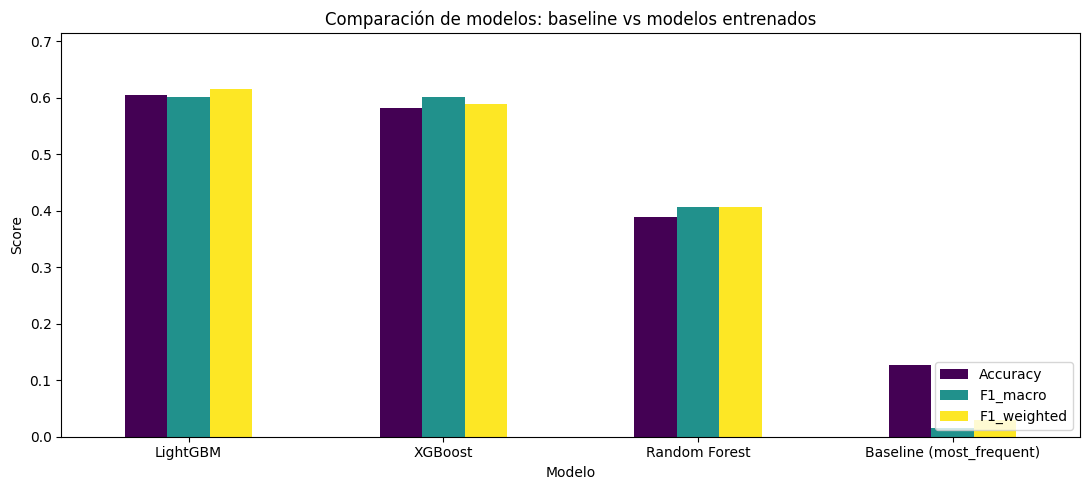

Mejor modelo según F1_weighted: LightGBM (0.6145)
Mejora vs baseline en F1_weighted: 0.5856


In [76]:
fig, ax = plt.subplots(figsize=(11, 5))

comparacion.set_index("Modelo")[["Accuracy", "F1_macro", "F1_weighted"]].plot(
    kind="bar",
    ax=ax,
    colormap="viridis"
)

ax.set_title("Comparación de modelos: baseline vs modelos entrenados")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.set_ylim(0, max(0.7, comparacion[["Accuracy", "F1_macro", "F1_weighted"]].max().max() + 0.1))
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

mejor_modelo_grafico = comparacion.iloc[0]["Modelo"]
mejor_f1 = comparacion.iloc[0]["F1_weighted"]

print(f"Mejor modelo según F1_weighted: {mejor_modelo_grafico} ({mejor_f1:.4f})")
print(f"Mejora vs baseline en F1_weighted: {mejor_f1 - metrics_dummy['F1_weighted']:.4f}")

### Impacto del modelo respecto al baseline

La mejora observada en F1_weighted confirma que los modelos supervisados capturan patrones relevantes en el comportamiento del cliente, superando ampliamente un enfoque simple basado en la frecuencia.

Esto refuerza la utilidad del modelo para aplicaciones reales de recomendación y segmentación.

### 5.1 Análisis de trade-offs

| Dimensión           | Baseline | Random Forest | XGBoost | LightGBM |
|---------------------|----------|---------------|---------|----------|
| F1_weighted         | 0.03     | 0.40          | 0.58    | 0.61     |
| Velocidad fit       | —        | media         | media   | rápida   |
| Interpretabilidad   | —        | alta          | media   | media    |
| Manejo desbalance   | —        | limitado      | limitado| bueno    |

**¿Por qué LightGBM sobre XGBoost si la diferencia es pequeña?**

Aunque XGBoost presenta un desempeño competitivo, LightGBM logra el mejor F1_weighted y además presenta mayor eficiencia computacional. Esto lo hace más adecuado para escenarios productivos donde el tiempo de respuesta es relevante.

Por otro lado, Random Forest, aunque más interpretable, presenta menor desempeño predictivo, por lo que no resulta la mejor opción en este caso.

Si el objetivo fuera maximizar la interpretabilidad, Random Forest podría ser considerado. Si se priorizara F1_macro en lugar de F1_weighted, XGBoost podría ser una alternativa válida.

La elección final de LightGBM se basa en el mejor balance entre rendimiento, eficiencia y robustez frente al desbalance de clases.

### Interpretación de resultados

A partir de la comparación de modelos, se observa que **LightGBM** presenta el mejor desempeño general, alcanzando el mayor valor de **F1_weighted (0.6145)**.

Este resultado indica un mejor equilibrio entre precisión y recall considerando el desbalance de clases, lo cual es clave en problemas reales de clasificación.

Por otro lado:

- **XGBoost** muestra un rendimiento competitivo, aunque levemente inferior.
- **Random Forest** queda considerablemente por debajo en todas las métricas.
- El modelo **baseline (DummyClassifier)** presenta resultados muy bajos, lo que confirma que los modelos entrenados aportan valor real.

En términos cuantitativos, el mejor modelo logra una mejora de **+0.5856 en F1_weighted** respecto al baseline, lo cual representa una mejora sustancial en la capacidad predictiva.

### Conclusión

Se selecciona **LightGBM como modelo final**, ya que:

- Maximiza la métrica principal (F1_weighted)
- Maneja mejor el desbalance de clases
- Ofrece el mejor rendimiento global

Este modelo será utilizado en la siguiente etapa para un análisis más profundo, incluyendo:
- Matriz de confusión
- Reporte de clasificación
- Importancia de variables

## 6. Análisis del mejor modelo

Se analiza en detalle el modelo con mejor `F1_weighted`: reporte de clasificación, importancia de features y matriz de confusión.

In [77]:
modelos_dict = {
    "Random Forest": (rf, pred_rf),
    "XGBoost": (xgb, pred_xgb),
    "LightGBM": (lgbm, pred_lgbm),
}

mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_modelo, mejor_pred = modelos_dict[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

Mejor modelo: LightGBM


In [78]:
from sklearn.metrics import classification_report

print("=== Reporte de Clasificación ===\n")

print(classification_report(
    y_test,
    mejor_pred,
    target_names=le.classes_,
    zero_division=0
))

=== Reporte de Clasificación ===

                        precision    recall  f1-score   support

            automotivo       0.28      0.54      0.37       870
                 bebes       0.40      0.59      0.47       638
          beleza_saude       0.84      0.60      0.70      1993
            brinquedos       0.38      0.56      0.46       853
       cama_mesa_banho       0.80      0.57      0.67      2359
            cool_stuff       0.62      0.72      0.67       796
           eletronicos       0.56      0.74      0.64       569
         esporte_lazer       0.60      0.48      0.53      1785
    ferramentas_jardim       0.75      0.76      0.75       914
informatica_acessorios       0.83      0.67      0.74      1616
      moveis_decoracao       0.67      0.54      0.60      1743
            perfumaria       0.54      0.64      0.59       712
    relogios_presentes       0.68      0.72      0.70      1239
             telefonia       0.53      0.69      0.60       942
 util

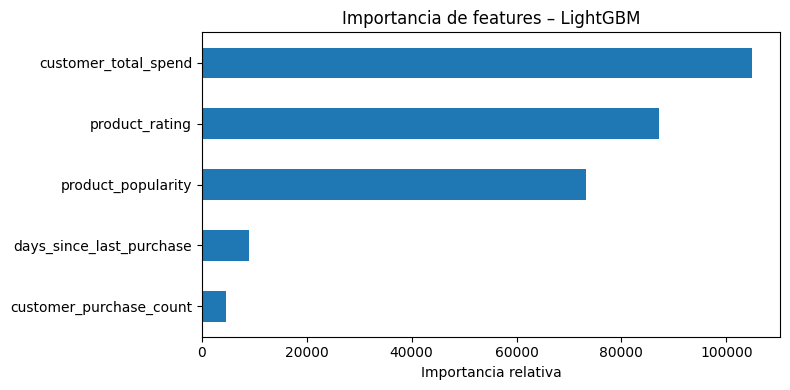

In [79]:
importances = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title(f"Importancia de features – {mejor_nombre}")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

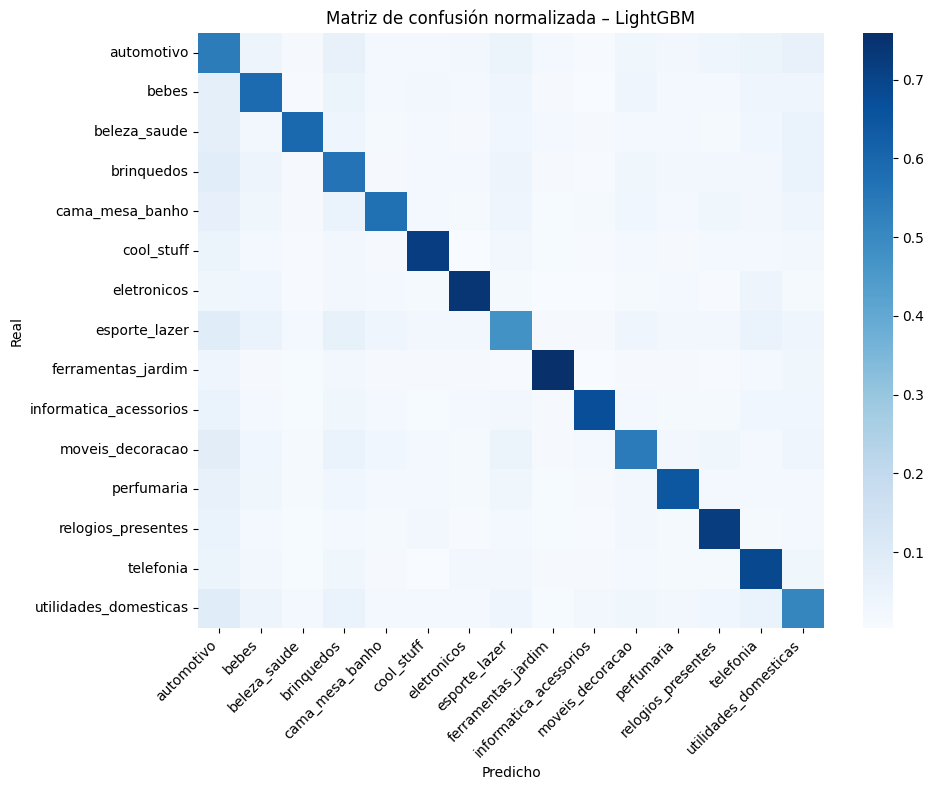

In [80]:
cm = confusion_matrix(y_test, mejor_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_title(f"Matriz de confusión normalizada – {mejor_nombre}")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación del modelo

El modelo LightGBM fue seleccionado como el mejor en base a la métrica F1_weighted, alcanzando un valor de aproximadamente 0.61, lo que indica un buen equilibrio entre precisión y recall en un contexto de clases desbalanceadas.

### Análisis del desempeño

El reporte de clasificación muestra que:

- Categorías como **beleza_saude**, **informatica_acessorios** y **ferramentas_jardim** presentan un desempeño sólido, con F1-score superiores a 0.70.
- Otras categorías como **automotivo** y **brinquedos** presentan menor precisión, lo que indica mayor dificultad para ser correctamente clasificadas.
- El F1_macro (~0.60) confirma que el modelo aún tiene margen de mejora en categorías minoritarias.

La matriz de confusión permite identificar que:

- Existe confusión entre categorías con comportamientos similares
- El modelo tiende a acertar mejor en categorías con mayor cantidad de datos (soporte)
- Algunas clases presentan dispersión, indicando solapamiento entre categorías

### Importancia de variables

El análisis de importancia de variables revela que:

- **customer_total_spend** es la variable más influyente, indicando que el nivel de gasto del cliente es clave para predecir la categoría de compra.
- **product_rating** y **product_popularity** también tienen un peso significativo, reflejando la relevancia del comportamiento agregado del producto.
- Variables como **days_since_last_purchase** y **customer_purchase_count** tienen menor impacto relativo.

Esto sugiere que el modelo está capturando principalmente patrones de comportamiento económico del cliente más que patrones temporales.

### Conclusión del análisis

El modelo logra un desempeño sólido considerando la complejidad del problema (múltiples clases y desbalance), pero presenta limitaciones en la discriminación de categorías similares.

A pesar de esto, los resultados son suficientemente robustos para su aplicación en sistemas de recomendación o segmentación de clientes.

### 6.5 Ejemplo de uso del modelo

Se simula la predicción de categorías para nuevos clientes con distintos perfiles de comportamiento, con el objetivo de ilustrar cómo el modelo puede ser utilizado en un entorno real.

In [81]:
# ================================
# Ejemplo de predicción
# ================================

nuevos_clientes = pd.DataFrame([
    {
        "customer_purchase_count": 8,
        "product_popularity": 200,
        "product_rating": 4.5,
        "customer_total_spend": 520.0,
        "days_since_last_purchase": 15,
    },
    {
        "customer_purchase_count": 1,
        "product_popularity": 30,
        "product_rating": 3.1,
        "customer_total_spend": 45.0,
        "days_since_last_purchase": 120,
    },
])

predicciones = le.inverse_transform(mejor_modelo.predict(nuevos_clientes))

for i, (_, row) in enumerate(nuevos_clientes.iterrows()):
    print(f"Cliente {i+1} → categoría recomendada: {predicciones[i]}")
    print(f"   Gasto total: ${row['customer_total_spend']} | Compras: {int(row['customer_purchase_count'])}\n")

Cliente 1 → categoría recomendada: cama_mesa_banho
   Gasto total: $520.0 | Compras: 8

Cliente 2 → categoría recomendada: informatica_acessorios
   Gasto total: $45.0 | Compras: 1



### Integración con sistema de recomendación

El modelo de clasificación puede integrarse con un sistema basado en ALS:

- ALS se utiliza para recomendar productos a usuarios con historial.
- El modelo supervisado se utiliza para usuarios nuevos (cold start), prediciendo la categoría más probable.

De esta forma, se construye un sistema híbrido que combina personalización y cobertura.

_____________________________________________________________________________

## 7. Conclusiones

### Síntesis de la comparación

- Los modelos entrenados superan ampliamente al baseline `most_frequent`, confirmando que las variables de comportamiento aportan señal útil para predecir categorías de compra.
- LightGBM obtiene el mejor desempeño general, con un F1_weighted aproximado de 0.61, seguido de cerca por XGBoost.
- Random Forest presenta menor desempeño predictivo, aunque mantiene mayor interpretabilidad.
- El F1_macro se mantiene cercano a 0.60, lo que evidencia que todavía existen dificultades para clasificar correctamente algunas categorías minoritarias.

### Limitaciones del dataset y del enfoque

- El modelo utiliza solo 5 features numéricas agregadas; variables como ciudad del cliente, método de pago, horario de compra, estacionalidad, precio, embeddings de producto o texto de reseñas podrían mejorar la predicción.
- La reducción a las Top 15 categorías mejora la estabilidad del entrenamiento, pero introduce sesgo hacia categorías populares y deja fuera categorías long tail.
- Existe solapamiento entre categorías con patrones de compra similares, lo que dificulta la separación perfecta entre clases.
- El modelo predice categorías de producto, no productos específicos; por lo tanto, debe integrarse con otra lógica de recomendación para sugerir ítems concretos.
- Las variables `customer_total_spend`, `product_rating` y `product_popularity` concentran la mayor importancia, por lo que el modelo depende fuertemente de señales agregadas de comportamiento y popularidad.

### Próximos pasos

- Aplicar Grid Search u Optuna sobre LightGBM para optimizar hiperparámetros.
- Incorporar features categóricas, geográficas, temporales y transaccionales.
- Evaluar el desempeño por categoría para identificar con mayor precisión dónde falla el modelo.
- Integrar la predicción de categoría con ALS para recomendar productos concretos.
- Diseñar una estrategia híbrida que combine ALS, clasificación supervisada y popularidad para distintos niveles de historial del usuario.